In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import pandas as pd
import numpy as np
import cmcrameri.cm as cmc

import aslice

create objects to plot

In [2]:
names = ['U18_HS12_kp07_4.csv',
         'U18_HS12_kp16_4.csv']

k_wtds = [2.1767, 2.1940]
ustars = [0.674, 0.785]
c_wtds = [np.sqrt(9.81/k_wtd) for k_wtd in k_wtds]
sigmas = [0.14231, 0.23197]

slices = []
for i, name in enumerate(names):
    slice = aslice.AlphaSlice(name)
    slice.data['afluc'] = (np.log10(slice.data['alpha']) - np.log10(slice.data['alpha'].mean()))
    slices.append(slice)

    logmean = np.log10(slice.data['alpha'].mean())
    print('mean, log   : {:.2f}   ,   {:.2f}'.format(slice.data['alpha'].mean(), logmean))
    print('min, log    : {:.2f}   ,   {:.2f}   >   {:.2f}'.format(min(slice.data['alpha']),
                                                                  np.log10(min(slice.data['alpha'])),
                                                                  np.log10(min(slice.data['alpha'])) - logmean))
    print('max, log    : {:.2f}   ,   {:.2f}    >   {:.2f}'.format(max(slice.data['alpha']),
                                                                  np.log10(max(slice.data['alpha'])),
                                                                  np.log10(max(slice.data['alpha'])) - logmean))
    print('')


    slice.data['z0'] = np.sqrt((0.11 * 1.8e-5 / ustars[i])**2 + 
                               (slice.data['alpha'] * (slice.data['u'] - c_wtds[i]) / 
                               (slice.data['u'] + c_wtds[i]) * sigmas[i])**2)
# print(slices[0].data)


mean, log   : 0.23   ,   -0.63
min, log    : 0.12   ,   -0.92   >   -0.29
max, log    : 1.51   ,   0.18    >   0.81

mean, log   : 0.76   ,   -0.12
min, log    : 0.29   ,   -0.53   >   -0.41
max, log    : 2.62   ,   0.42    >   0.54



Text(0.5, 0, '$x$ (m)')

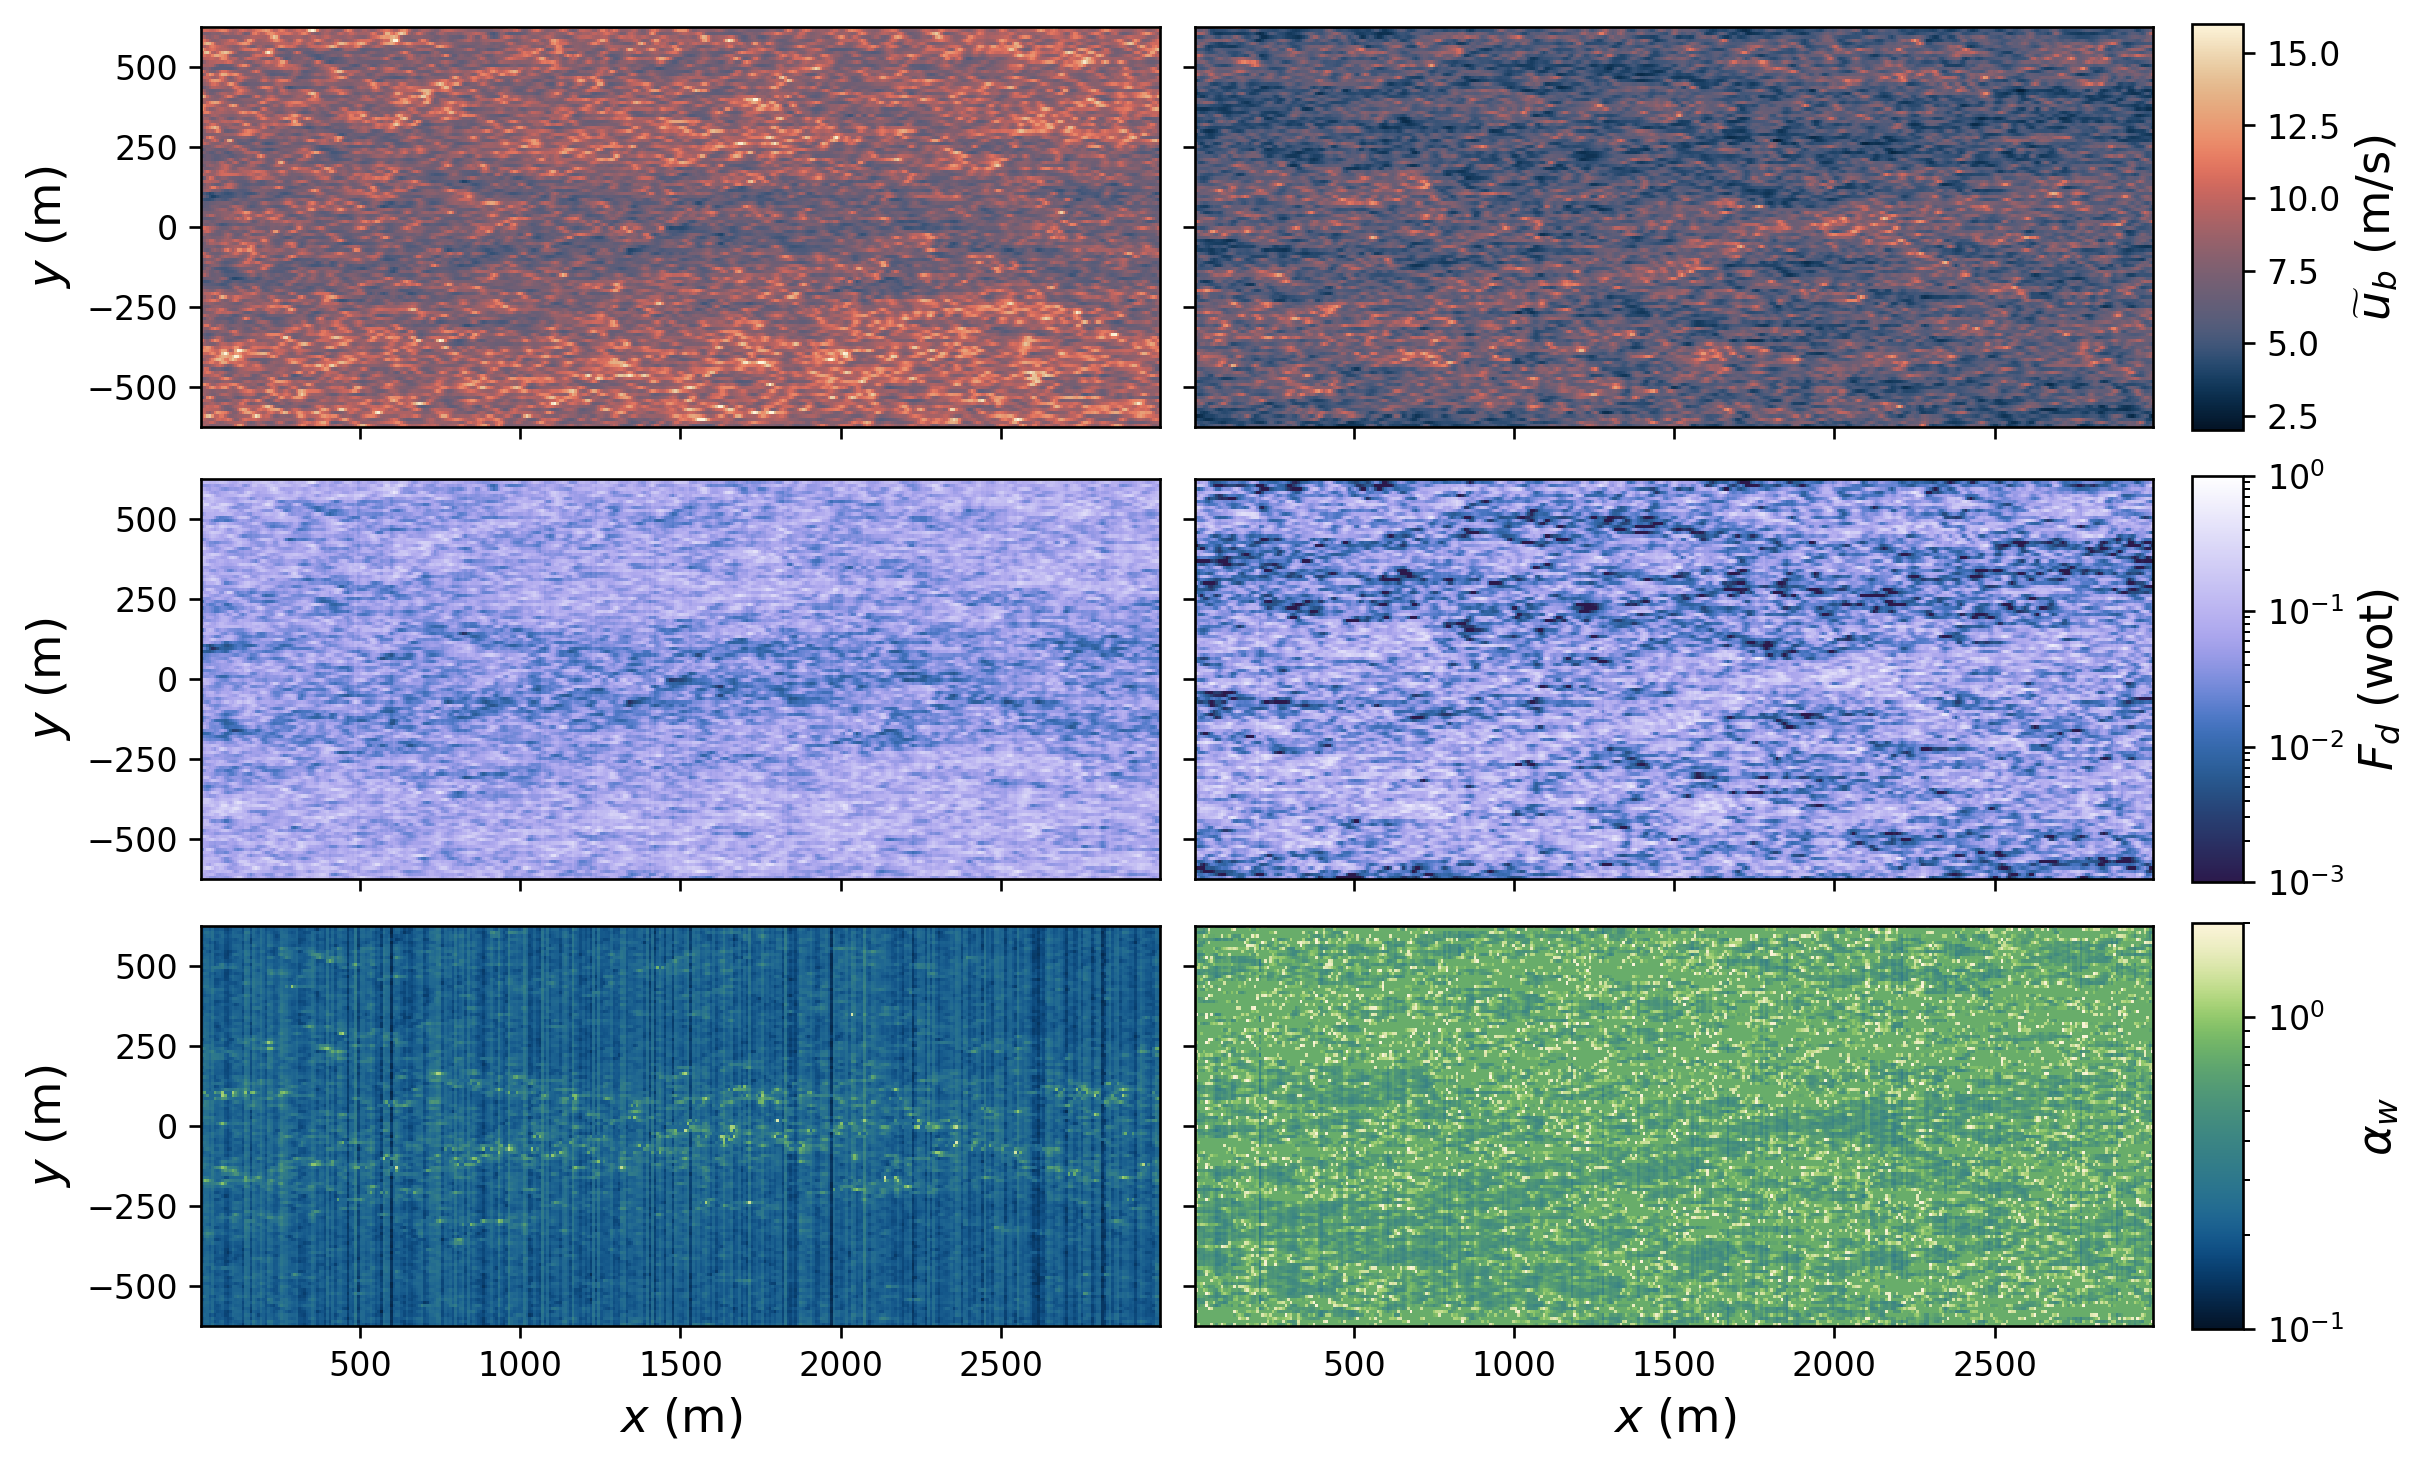

In [8]:
mpl.rcParams.update({'font.size': 10})
wordsize=14

fig, axs = plt.subplots(3, 2, dpi=240.0, figsize=(10,6), constrained_layout=True,#tight_layout=True,
                         sharey=True, sharex=True)


values = ['u', 'FD', 'alpha']
vlabels = [r'$\widetilde{u}_b$ (m/s)', r'$F_{d}$ (wot)', r'$\alpha_w$']
cmaps = {'u': cmc.lipari, 'FD': cmc.devon, 'alpha': cmc.navia}
norms = {'u': mpl.colors.Normalize(vmin=2, vmax=16),
        'FD': mpl.colors.LogNorm(vmin=1e-3, vmax=1),
        'alpha': mpl.colors.LogNorm(vmin=0.1, vmax=2)}
# vlim = {'alpha':(0.1,2), 'u':(4,18), 'FD':(0,1)}

for vi, value in enumerate(values):
    # vmin, vmax = vlim[value]
    # norm = norms[value]
    rowmap = mpl.cm.ScalarMappable(norm=norms[value], cmap=cmaps[value])

    for si in range(len(slices)):
        slice = slices[si]
        # gridalpha = slice.data.pivot(index='x', columns='z', values='alpha')
        grid = slice.data.pivot(index='z', columns='x', values=value)

        if value == 'FD':
            grid[grid<1e-3] = 1e-3

        xvals = np.asarray(grid.columns, dtype=float)
        zvals = np.asarray(grid.index, dtype=float)


        axs[vi,si].imshow(grid, 
                          extent=[min(xvals), max(xvals), min(zvals), max(zvals)],
                          cmap=rowmap.cmap,
                          norm=norms[value],
                          aspect='equal',
                          interpolation='none'
                          )
        
    cbar = fig.colorbar(rowmap,
                        # cax=cax,
                        ax=axs[vi,:],
                        orientation='vertical',
                        pad=0.02,
                        aspect=8,
                        # shrink=0.85,
                        )
    cbar.set_label(vlabels[vi], fontsize=wordsize)
    
    axs[vi,0].set_ylabel(r'$y$ (m)', fontsize=wordsize)
    

axs[2,0].set_xlabel(r'$x$ (m)', fontsize=wordsize)
axs[2,1].set_xlabel(r'$x$ (m)', fontsize=wordsize)



Text(0.5, 0, '$x$ (m)')

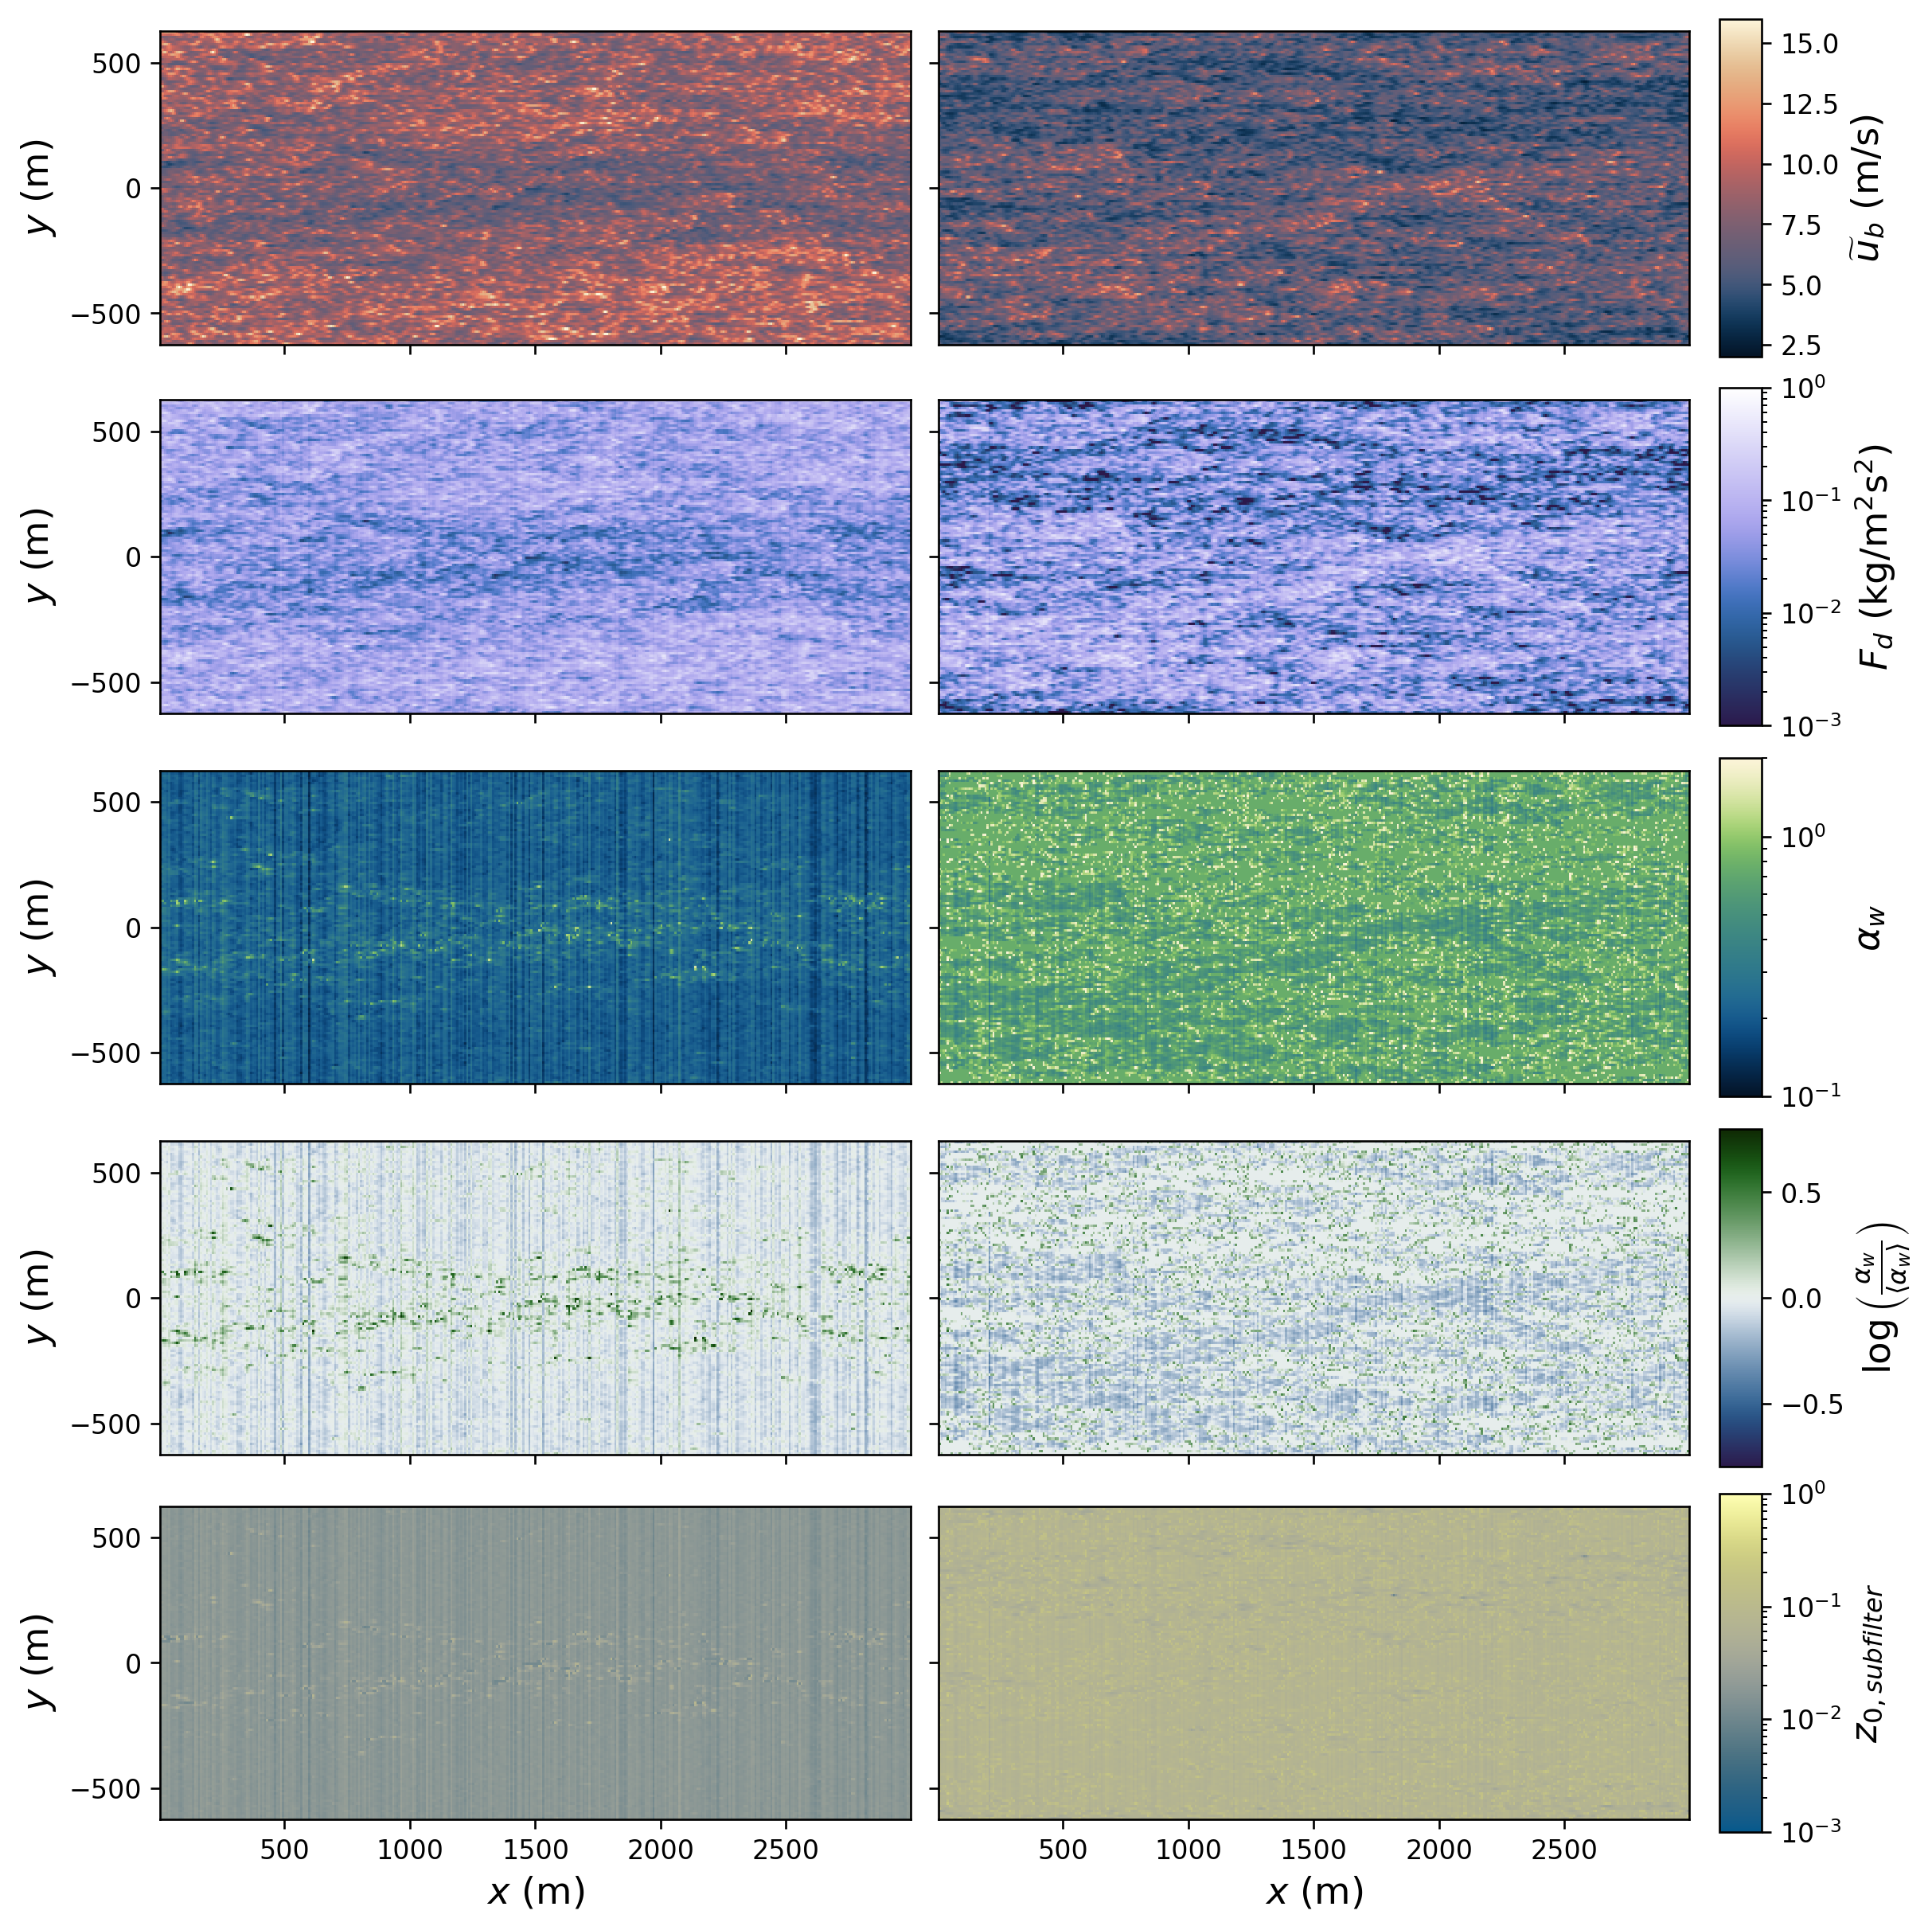

In [ ]:
mpl.rcParams.update({'font.size': 10})
wordsize=14

values = ['u', 'FD', 'alpha', 'afluc']#, 'z0']


vlabels = [r'$\widetilde{u}_b$ (m/s)', r'$F_{d}$ (kg/m$^2$s$^2$)', r'$\alpha_w$',
           r"$\log\left(\frac{\alpha_w}{\langle\alpha_w\rangle}\right)$", r'$z_{0, subfilter}$']
cmaps = {'u': cmc.lipari, 'FD': cmc.devon, 'alpha': cmc.navia, 'afluc': cmc.cork, 'z0': cmc.nuuk}
norms = {'u': mpl.colors.Normalize(vmin=2, vmax=16),
        'FD': mpl.colors.LogNorm(vmin=1e-3, vmax=1),
        'alpha': mpl.colors.LogNorm(vmin=0.1, vmax=2),
        'afluc': mpl.colors.Normalize(vmin=-0.8, vmax=0.8),
        'z0': mpl.colors.LogNorm(vmin=0.001, vmax=1)}
# vlim = {'alpha':(0.1,2), 'u':(4,18), 'FD':(0,1)}


fig, axs = plt.subplots(len(values), 2, dpi=240.0, figsize=(10, 2*len(values)),
                        constrained_layout=True,#tight_layout=True,
                        sharey=True, sharex=True)

for vi, value in enumerate(values):
    # vmin, vmax = vlim[value]
    # norm = norms[value]
    rowmap = mpl.cm.ScalarMappable(norm=norms[value], cmap=cmaps[value])

    for si in range(len(slices)):
        slice = slices[si]
        # gridalpha = slice.data.pivot(index='x', columns='z', values='alpha')
        grid = slice.data.pivot(index='z', columns='x', values=value)

        if value == 'FD':
            grid[grid<1e-3] = 1e-3

        xvals = np.asarray(grid.columns, dtype=float)
        zvals = np.asarray(grid.index, dtype=float)


        axs[vi,si].imshow(grid, 
                          extent=[min(xvals), max(xvals), min(zvals), max(zvals)],
                          cmap=rowmap.cmap,
                          norm=norms[value],
                          aspect='equal',
                          interpolation='none'
                          )
        
    cbar = fig.colorbar(rowmap,
                        # cax=cax,
                        ax=axs[vi,:],
                        orientation='vertical',
                        pad=0.02,
                        aspect=8,
                        # shrink=0.85,
                        )
    cbar.set_label(vlabels[vi], fontsize=wordsize)
    
    axs[vi,0].set_ylabel(r'$y$ (m)', fontsize=wordsize)
    

axs[len(values)-1,0].set_xlabel(r'$x$ (m)', fontsize=wordsize)
axs[len(values)-1,1].set_xlabel(r'$x$ (m)', fontsize=wordsize)

# fig.savefig('xyplane.pdf')